In [179]:
import sys
sys.path.append('../')
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle

from utils import *

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

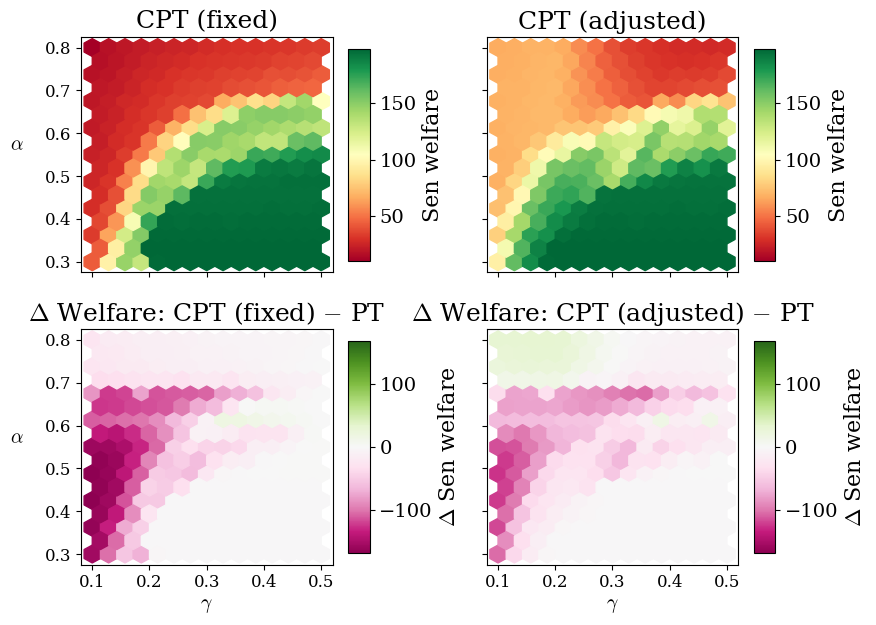

In [214]:
def load_flat_cpt(model_dir):
    """
    Load params and Sen welfare from a gamma_sweep CPT directory.
    Returns alpha, gamma, welfare as 1D arrays of same length.
    """
    with open(os.path.join(model_dir, "params"), "rb") as f:
        params = pickle.load(f)
    with open(os.path.join(model_dir, "sen_welfare"), "rb") as f:
        sen = pickle.load(f)

    params = np.array(params, dtype=float)
    sen = np.array(sen, dtype=float)

    # params[i] = (alpha, rate, A, lambda, gamma)
    alphas = params[:, 0]
    gammas = params[:, 4]

    return alphas, gammas, sen


def load_pt_alpha_means(model_dir):
    """
    Load PT gamma_sweep results and return a mapping alpha -> mean Sen(α).
    """
    with open(os.path.join(model_dir, "params"), "rb") as f:
        params = pickle.load(f)
    with open(os.path.join(model_dir, "sen_welfare"), "rb") as f:
        sen = pickle.load(f)

    params = np.array(params, dtype=float)
    sen = np.array(sen, dtype=float)

    alphas = params[:, 0]
    alpha_unique = np.unique(alphas)

    alpha_to_mean = {}
    for a in alpha_unique:
        alpha_to_mean[a] = float(np.mean(sen[np.isclose(alphas, a)]))

    return alpha_to_mean


# ---------------------------------------------------------------------
# Main plotting
# ---------------------------------------------------------------------

# Root dirs (without /raw)
cpt_fixed_root = "../data/gamma_sweep/cpt_no_distort"
cpt_max_root   = "../data/gamma_sweep/cpt_max_distort"
pt_root        = "../data/gamma_sweep/pt_no_distort"

# Load CPT (fixed) and CPT (maximal)
alpha_fixed, gamma_fixed, welfare_cpt_fixed = load_flat_cpt(cpt_fixed_root)
alpha_max,   gamma_max,   welfare_cpt_max   = load_flat_cpt(cpt_max_root)

# Sanity: same α–γ grid
assert np.allclose(alpha_fixed, alpha_max)
assert np.allclose(gamma_fixed, gamma_max)

alpha_vals = alpha_fixed
gamma_vals = gamma_fixed

# Load PT and map α -> Sen_PT(α)
alpha_to_pt = load_pt_alpha_means(pt_root)
welfare_pt_for_points = np.array([alpha_to_pt[a] for a in alpha_vals])

# Differences
diff_fixed = welfare_cpt_fixed - welfare_pt_for_points
diff_max   = welfare_cpt_max   - welfare_pt_for_points

# Global ranges for welfare panels
welfare_min = min(welfare_cpt_fixed.min(), welfare_cpt_max.min())
welfare_max = max(welfare_cpt_fixed.max(), welfare_cpt_max.max())

# Global symmetric range for difference panels
max_abs_diff = max(np.abs(diff_fixed).max(), np.abs(diff_max).max())

# ---------------------------------------------------------------------
# Figure: 2×2 hexbin panels
# ---------------------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(9, 6.5), sharex=True, sharey=True)

# Common kwargs for hexbin
hex_kwargs = dict(
    gridsize=14,
    mincnt=1,
    reduce_C_function=np.mean
)

# ---------------------------------------------------------------------
# (1) CPT welfare, fixed PH+, PH−
# ---------------------------------------------------------------------
ax = axs[0, 0]
norm_welfare = TwoSlopeNorm(
    vmin=welfare_min,
    vcenter=(welfare_min + welfare_max) / 2,
    vmax=welfare_max
)

hb1 = ax.hexbin(
    gamma_fixed,
    alpha_fixed,
    C=welfare_cpt_fixed,
    cmap="RdYlGn",
    norm=norm_welfare,
    **hex_kwargs
)

ax.set_title("CPT (fixed)")
ax.set_ylabel(r"$\alpha$", rotation=0, labelpad=20, fontsize=14)

cbar1 = fig.colorbar(hb1, ax=ax, shrink=0.9, aspect=10)
cbar1.set_label("Sen welfare")

# ---------------------------------------------------------------------
# (2) CPT welfare, maximal PH+, PH−
# ---------------------------------------------------------------------
ax = axs[0, 1]
hb2 = ax.hexbin(
    gamma_max,
    alpha_max,
    C=welfare_cpt_max,
    cmap="RdYlGn",
    norm=norm_welfare,
    **hex_kwargs
)

ax.set_title("CPT (adjusted)")

cbar2 = fig.colorbar(hb2, ax=ax, shrink=0.9, aspect=10)
cbar2.set_label("Sen welfare")

# ---------------------------------------------------------------------
# (3) Δ welfare: CPT (fixed) − PT
# ---------------------------------------------------------------------
ax = axs[1, 0]
norm_diff = TwoSlopeNorm(vmin=-max_abs_diff, vcenter=0.0, vmax=max_abs_diff)

hb3 = ax.hexbin(
    gamma_fixed,
    alpha_fixed,
    C=diff_fixed,
    cmap="PiYG",
    norm=norm_diff,
    **hex_kwargs
)

ax.set_title(r"$\Delta$ Welfare: CPT (fixed) $-$ PT")
ax.set_xlabel(r"$\gamma$", fontsize=14)
ax.set_ylabel(r"$\alpha$", rotation=0, labelpad=20, fontsize=14)

cbar3 = fig.colorbar(hb3, ax=ax, shrink=0.9, aspect=10)
cbar3.set_label(r"$\Delta$ Sen welfare")

# ---------------------------------------------------------------------
# (4) Δ welfare: CPT (max-distortion) − PT
# ---------------------------------------------------------------------
ax = axs[1, 1]
hb4 = ax.hexbin(
    gamma_max,
    alpha_max,
    C=diff_max,
    cmap="PiYG",
    norm=norm_diff,
    **hex_kwargs
)

ax.set_title(r"$\Delta$ Welfare: CPT (adjusted) $-$ PT")
ax.set_xlabel(r"$\gamma$", fontsize=14)

cbar4 = fig.colorbar(hb4, ax=ax, shrink=0.9, aspect=10)
cbar4.set_label(r"$\Delta$ Sen welfare")

# ---------------------------------------------------------------------
# Final layout / save
# ---------------------------------------------------------------------
for ax in axs.flat:
    ax.tick_params(labelsize=12)

fig.tight_layout()

# Optional: save
# plt.savefig("fig_gamma_sweep_cpt_pt.pdf", bbox_inches="tight")

plt.show()

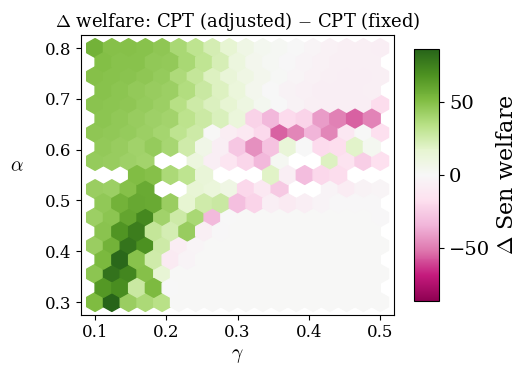

In [ ]:
diff_cpt = welfare_cpt_max - welfare_cpt_fixed
max_abs_cpt = np.abs(diff_cpt).max()

fig_diff, ax = plt.subplots(figsize=(5.5, 4))

norm_cpt = TwoSlopeNorm(vmin=-max_abs_cpt, vcenter=0.0, vmax=max_abs_cpt)

hb_cpt = ax.hexbin(
    gamma_fixed,
    alpha_fixed,
    C=diff_cpt,
    cmap="PiYG",
    norm=norm_cpt,
    gridsize=17,
    mincnt=1,
    reduce_C_function=np.mean
)

ax.set_xlabel(r"$\gamma$", fontsize=14)
ax.set_ylabel(r"$\alpha$", rotation=0, labelpad=20, fontsize=14)
ax.set_title(r"$\Delta$ welfare: CPT (adjusted) $-$ CPT (fixed)", fontsize=13)

cbar_cpt = fig_diff.colorbar(hb_cpt, ax=ax, shrink=0.9, aspect=10)
cbar_cpt.set_label(r"$\Delta$ Sen welfare")

ax.tick_params(labelsize=12)
fig_diff.tight_layout()

# Optional: save
# plt.savefig("fig_gamma_sweep_cpt_diff.pdf", bbox_inches="tight")

plt.show()

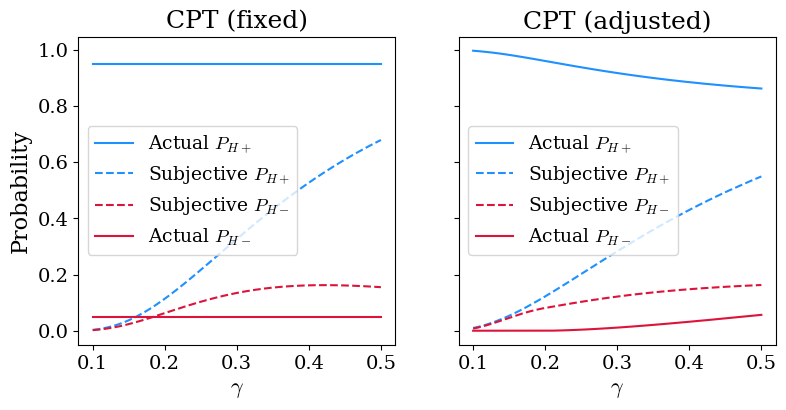

In [211]:
gamma_linspace = np.linspace(0.1, 0.50, 1000)
pvals = np.linspace(0.001,0.999,10000)
under = []
over = []
for g in gamma_linspace:
    most_underweighted = pvals[np.argmin(pvals - probability_weighting(pvals, gamma=g))]
    most_overweighted = pvals[np.argmax(pvals - probability_weighting(pvals, gamma=g))]
    under.append(most_underweighted)
    over.append(most_overweighted)


fig, axs = plt.subplots(1, 2, figsize=(9,4), sharey=True)

# CPT fixed 
axs[0].plot(gamma_linspace, [0.95]*len(gamma_linspace), color="dodgerblue", label=r"Actual $P_{H+}$")
axs[0].plot(
    gamma_linspace,
    [probability_weighting(0.95, gamma=gamma_linspace[i]) for i in range(len(gamma_linspace))],
    color="dodgerblue",
    linestyle="dashed",
    label=r"Subjective $P_{H+}$"
)
axs[0].plot(
    gamma_linspace,
    [probability_weighting(0.05, gamma=gamma_linspace[i]) for i in range(len(gamma_linspace))],
    color="crimson",
    linestyle="dashed",
    label=r"Subjective $P_{H-}$"
)
axs[0].plot(gamma_linspace, [0.05]*len(gamma_linspace), color="crimson", label=r"Actual $P_{H-}$")
axs[0].set_xlabel(r"$\gamma$")
axs[0].set_ylabel("Probability")
axs[0].set_title("CPT (fixed)")
axs[0].legend()

# CPT adjusted
axs[1].plot(gamma_linspace, over, color="dodgerblue", label=r"Actual $P_{H+}$")
axs[1].plot(
    gamma_linspace,
    [probability_weighting(over[i], gamma=gamma_linspace[i]) for i in range(len(gamma_linspace))],
    color="dodgerblue",
    linestyle="dashed",
    label=r"Subjective $P_{H+}$"
)
axs[1].plot(
    gamma_linspace,
    [probability_weighting(under[i], gamma=gamma_linspace[i]) for i in range(len(gamma_linspace))],
    color="crimson",
    linestyle="dashed",
    label=r"Subjective $P_{H-}$"
)
axs[1].plot(gamma_linspace, under, color="crimson", label=r"Actual $P_{H-}$")
axs[1].set_xlabel(r"$\gamma$")
axs[1].legend()
axs[1].set_title("CPT (adjusted)")

plt.show()